# 01 · Kalshi BTC markets in five minutes

**Kalshi** is a US exchange (CFTC-regulated) for event contracts. Each contract pays **$1 if the event
happens and $0 if not**, so its price in cents reads directly as the crowd's probability.

This project looks at two recurring Bitcoin markets:

| | **KXBTC15M** — 15-minute up/down | **KXBTCD** — hourly strike ladder |
|---|---|---|
| Question | "Will BTC be higher at the end of this 15-minute window than at its start?" | "Will BTC be above $K at the top of the hour?" for a ladder of strikes K |
| New market | every 15 minutes, 96 per day | every hour, many strikes per hour |
| Settles on | the 60-second average of the CF Benchmarks BRTI index before close | same |
| Price | 1–99 ¢ = implied probability | same |

**Buying and fees.** You buy YES at the *ask* or NO at 100 − *bid*. A taker pays
`0.07 × C × (1 − C)` dollars per contract (C = price in dollars). That is 1.75 ¢ at 50 ¢, the most
expensive point, so any edge has to clear the fee first.

**The trading idea in one line:** the contract price is already a forecast. A model is only useful if
its probability is *better than the price*, by more than the fee, on contracts you can actually buy.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tabtrader import plots
plots.style()
pd.set_option("display.width", 140, "display.max_columns", 30)

In [2]:
raw = ROOT / "data" / "raw_week"
q15 = pd.read_parquet(raw / "kxbtc15m_quotes_1s.parquet")
s15 = pd.read_parquet(raw / "settlements_15m.parquet")
print(f"one week of 15-minute markets: {s15.market.nunique()} markets, {len(q15):,} one-second quote rows")
s15.head()

one week of 15-minute markets: 665 markets, 563,298 one-second quote rows


,market,open_time,close_time,strike,label
0,KXBTC15M-26SEP252000-00,2026-09-25 23:45:00+00:00,2026-09-26 00:00:00+00:00,84066.84,1
1,KXBTC15M-26SEP252015-15,2026-09-26 00:00:00+00:00,2026-09-26 00:15:00+00:00,84091.04,0
2,KXBTC15M-26SEP252030-30,2026-09-26 00:15:00+00:00,2026-09-26 00:30:00+00:00,84077.82,0
3,KXBTC15M-26SEP252045-45,2026-09-26 00:30:00+00:00,2026-09-26 00:45:00+00:00,83937.53,0
4,KXBTC15M-26SEP252100-00,2026-09-26 00:45:00+00:00,2026-09-26 01:00:00+00:00,83889.72,0


### One 15-minute market, second by second

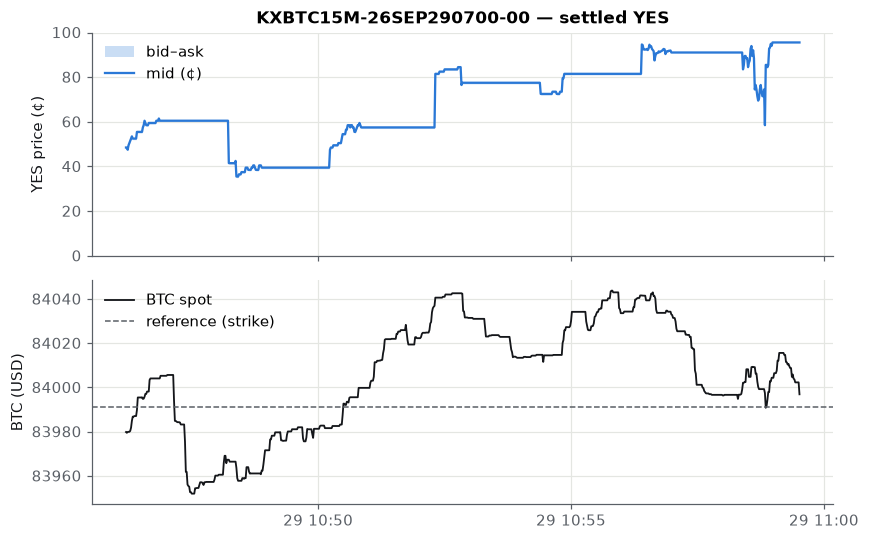

In [3]:
m = s15.iloc[len(s15) // 2]
g = q15[q15.market == m.market].sort_values("sec_end")
g = g[g.quote_valid == 1]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
a1.fill_between(g.sec_end, g.bid, g.ask, color=plots.TABPFN, alpha=.25, lw=0, label="bid–ask")
a1.plot(g.sec_end, (g.bid + g.ask) / 2, color=plots.TABPFN, lw=1.5, label="mid (¢)")
a1.set_ylabel("YES price (¢)"); a1.set_ylim(0, 100); a1.legend(loc="upper left")
a1.set_title(f"{m.market} — settled {'YES' if m.label else 'NO'}")
a2.plot(g.sec_end, g.btc, color=plots.INK, lw=1.2, label="BTC spot")
a2.axhline(m.strike, color=plots.MUTED, ls="--", lw=1, label="reference (strike)")
a2.set_ylabel("BTC (USD)"); a2.legend(loc="upper left")
plt.tight_layout()

### The hourly ladder at one instant (30 minutes before close)

,market,strike,bid,ask,mid,label
0,KXBTCD-26SEP2815-T83799.99,83799.99,74.0,75.0,74.5,1
1,KXBTCD-26SEP2815-T83899.99,83899.99,52.0,53.0,52.5,1
2,KXBTCD-26SEP2815-T83599.99,83599.99,94.0,95.0,94.5,1
3,KXBTCD-26SEP2815-T83699.99,83699.99,88.0,89.0,88.5,1
4,KXBTCD-26SEP2815-T83999.99,83999.99,30.0,31.0,30.5,1


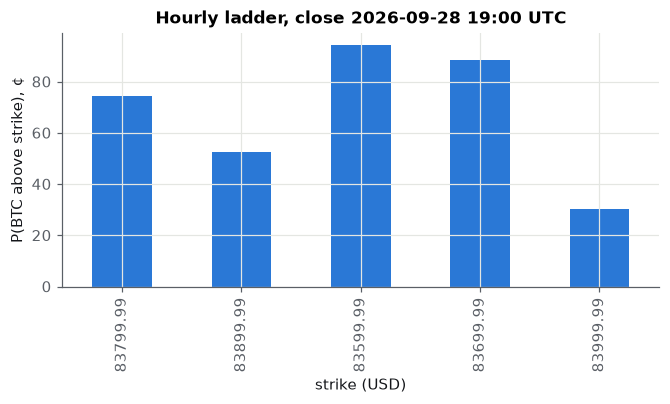

In [4]:
qh = pd.read_parquet(raw / "kxbtcd_quotes_10s.parquet")
sh = pd.read_parquet(raw / "settlements_1h.parquet")
ev = sh.close_time.value_counts().index[len(sh.close_time.unique()) // 2]
legs = sh[sh.close_time == ev].sort_values("strike")
t = ev - pd.Timedelta(minutes=30)
snap = (qh[qh.market.isin(legs.market) & (qh.sec_end <= t) & (qh.quote_valid == 1)]
        .sort_values("sec_end").groupby("market").tail(1).merge(legs, on="market"))
snap["mid"] = (snap.bid + snap.ask) / 2
ax = snap.plot.bar(x="strike", y="mid", color=plots.TABPFN, legend=False, figsize=(7, 3))
ax.set_ylabel("P(BTC above strike), ¢"); ax.set_xlabel("strike (USD)")
ax.set_title(f"Hourly ladder, close {ev:%Y-%m-%d %H:%M} UTC")
snap[["market", "strike", "bid", "ask", "mid", "label"]]

### The fee curve

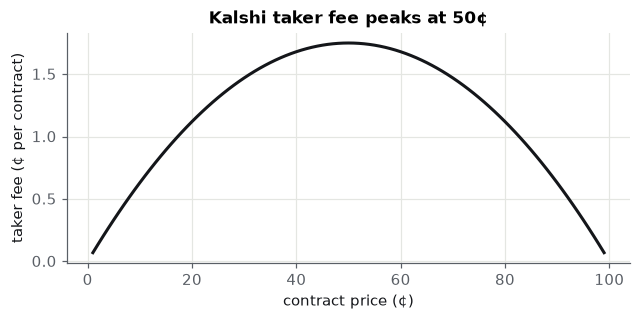

In [5]:
from tabtrader.evaluate import fee_c
c = np.arange(1, 100)
plt.figure(figsize=(6, 3))
plt.plot(c, fee_c(c), color=plots.INK)
plt.xlabel("contract price (¢)"); plt.ylabel("taker fee (¢ per contract)")
plt.title("Kalshi taker fee peaks at 50¢"); plt.tight_layout()